In [1]:
# ============================================================
# NOTEBOOK 09 — MODEL EXPLAINABILITY + VERSIONING
# Enterprise HR AI — Workforce Intelligence & Upskilling Platform
# ============================================================

print("=" * 70)
print("NOTEBOOK 09 — MODEL EXPLAINABILITY + VERSIONING")
print("=" * 70)

NOTEBOOK 09 — MODEL EXPLAINABILITY + VERSIONING


In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


In [3]:
# ============================================================
# PROJECT PATHS
# ============================================================

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent

FEATURE_ENGINEERED_PATH = (
    PROJECT_ROOT / "data" / "feature_engineered"
)

MODEL_PATH = (
    PROJECT_ROOT / "models"
)

OUTPUT_PATH = (
    PROJECT_ROOT / "data" / "eda_outputs"
)

VERSION_PATH = (
    MODEL_PATH / "v1"
)

print("Project Root:")
print(PROJECT_ROOT)

print("\nFeature Engineered Data:")
print(FEATURE_ENGINEERED_PATH)

print("\nModels:")
print(MODEL_PATH)

print("\nVersion Folder:")
print(VERSION_PATH)

Project Root:
C:\Users\Shubham\Desktop\enterprise_hr_ai

Feature Engineered Data:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\feature_engineered

Models:
C:\Users\Shubham\Desktop\enterprise_hr_ai\models

Version Folder:
C:\Users\Shubham\Desktop\enterprise_hr_ai\models\v1


In [4]:
# ============================================================
# LOAD FEATURE ENGINEERED DATA
# ============================================================

feature_file = FEATURE_ENGINEERED_PATH / "employee_features.csv"

if not feature_file.exists():
    raise FileNotFoundError(
        f"Feature file not found:\n{feature_file}"
    )

df = pd.read_csv(feature_file)

print(f"✓ Loaded employee feature dataset.")
print(f"Shape: {df.shape}")

display(df.head())

✓ Loaded employee feature dataset.
Shape: (1470, 47)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,ExperienceGroup,CompanyTenureGroup,OverallSatisfactionScore,SatisfactionCategory,OverTimeRisk,LongCommuteRisk,LowIncomeRisk,FrequentJobChangeRisk,AttritionRiskScore,AttritionRiskCategory
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,6-10 Years,6-10 Years,2.00,Low Satisfaction,High Risk,Lower Risk,Lower Risk,High Risk,5,High Risk
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,6-10 Years,6-10 Years,3.00,Medium Satisfaction,Lower Risk,Lower Risk,Lower Risk,Lower Risk,0,Low Risk
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,6-10 Years,0-1 Year,3.00,Medium Satisfaction,High Risk,Lower Risk,High Risk,High Risk,4,High Risk
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,6-10 Years,6-10 Years,3.25,High Satisfaction,High Risk,Lower Risk,High Risk,Lower Risk,3,Medium Risk
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,6-10 Years,2-3 Years,2.50,Medium Satisfaction,Lower Risk,Lower Risk,Lower Risk,High Risk,3,Medium Risk


In [5]:
# ============================================================
# CREATE TARGET VARIABLE
# ============================================================

if "AttritionTarget" in df.columns:
    y = df["AttritionTarget"].astype(int)

elif "Attrition" in df.columns:
    y = (
        df["Attrition"]
        .map({"Yes": 1, "No": 0})
        .astype(int)
    )

else:
    raise ValueError(
        "Neither AttritionTarget nor Attrition column found."
    )

print("✓ Target variable prepared.")

print("\nTarget distribution:")
print(y.value_counts())

✓ Target variable prepared.

Target distribution:
0    1233
1     237
Name: Attrition, dtype: int64


In [7]:
# ============================================================
# MODEL FEATURES + ENGINEERED FEATURES
# ============================================================

# Recreate the engineered features used by the attrition model

df["IncomePerYearExperience"] = (
    (df["MonthlyIncome"] * 12) /
    df["TotalWorkingYears"].replace(0, np.nan)
).fillna(0)

df["CompanyTenureRatio"] = (
    df["YearsAtCompany"] /
    df["TotalWorkingYears"].replace(0, np.nan)
).fillna(0)

df["PromotionWaitRatio"] = (
    df["YearsSinceLastPromotion"] /
    df["YearsAtCompany"].replace(0, np.nan)
).fillna(0)

df["OverallSatisfactionScore"] = (
    df["EnvironmentSatisfaction"]
    + df["JobSatisfaction"]
    + df["RelationshipSatisfaction"]
    + df["WorkLifeBalance"]
) / 4

df["CareerStabilityScore"] = (
    df["YearsAtCompany"]
    + df["YearsInCurrentRole"]
    + df["YearsWithCurrManager"]
) / 3


# ------------------------------------------------------------
# FEATURES USED BY THE FINAL MODEL
# ------------------------------------------------------------

feature_columns = [
    "Age",
    "OverTime",
    "JobSatisfaction",
    "MonthlyIncome",
    "YearsAtCompany",
    "WorkLifeBalance",
    "TotalWorkingYears",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "JobLevel",
    "JobInvolvement",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "DistanceFromHome",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "StockOptionLevel",
    "TrainingTimesLastYear",
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus",
    "Gender",
    "IncomePerYearExperience",
    "CompanyTenureRatio",
    "PromotionWaitRatio",
    "OverallSatisfactionScore",
    "CareerStabilityScore"
]


missing_features = [
    col for col in feature_columns
    if col not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing model features: {missing_features}"
    )

X = df[feature_columns].copy()

print("✓ Engineered features recreated.")
print(f"✓ Features prepared: {X.shape[1]}")
print(f"✓ Records prepared: {X.shape[0]}")

print("\nEngineered features:")
print([
    "IncomePerYearExperience",
    "CompanyTenureRatio",
    "PromotionWaitRatio",
    "OverallSatisfactionScore",
    "CareerStabilityScore"
])

✓ Engineered features recreated.
✓ Features prepared: 30
✓ Records prepared: 1470

Engineered features:
['IncomePerYearExperience', 'CompanyTenureRatio', 'PromotionWaitRatio', 'OverallSatisfactionScore', 'CareerStabilityScore']


In [8]:
# ============================================================
# RECREATE TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✓ Train/Test split recreated.")
print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

✓ Train/Test split recreated.
Training rows : 1176
Testing rows  : 294


In [10]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

best_model_path = MODEL_PATH / "best_attrition_model.joblib"

if not best_model_path.exists():
    raise FileNotFoundError(
        f"Best model not found:\n{best_model_path}"
    )

best_model = joblib.load(best_model_path)

print("✓ Best model loaded successfully.")
print(f"Model file: {best_model_path.name}")

✓ Best model loaded successfully.
Model file: best_attrition_model.joblib


In [11]:
# ============================================================
# CONFIRM MODEL TYPE
# ============================================================

print("Loaded model object:")
print(best_model)

print("\nFinal model:")
print(best_model.named_steps["model"])

Loaded model object:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'YearsAtCompany',
                                                   'WorkLifeBalance',
                                                   'TotalWorkingYears',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                 

In [12]:
# ============================================================
# GET TRANSFORMED FEATURE NAMES
# ============================================================

preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

print(f"✓ Transformed feature count: {len(feature_names)}")

print("\nFirst 20 transformed features:")
for feature in feature_names[:20]:
    print(feature)

✓ Transformed feature count: 47

First 20 transformed features:
numeric__Age
numeric__JobSatisfaction
numeric__MonthlyIncome
numeric__YearsAtCompany
numeric__WorkLifeBalance
numeric__TotalWorkingYears
numeric__YearsInCurrentRole
numeric__YearsSinceLastPromotion
numeric__YearsWithCurrManager
numeric__JobLevel
numeric__JobInvolvement
numeric__EnvironmentSatisfaction
numeric__RelationshipSatisfaction
numeric__DistanceFromHome
numeric__NumCompaniesWorked
numeric__PercentSalaryHike
numeric__StockOptionLevel
numeric__TrainingTimesLastYear
numeric__OverallSatisfactionScore
categorical__OverTime_No


In [13]:
# ============================================================
# MODEL COEFFICIENTS
# ============================================================

coefficients = model.coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsoluteImportance": np.abs(coefficients)
})

coefficient_df = coefficient_df.sort_values(
    by="AbsoluteImportance",
    ascending=False
).reset_index(drop=True)

display(coefficient_df.head(20))

,Feature,Coefficient,AbsoluteImportance
0,categorical__JobRole_Laboratory Technician,1.028829,1.028829
1,categorical__JobRole_Research Director,-0.997593,0.997593
2,categorical__BusinessTravel_Non-Travel,-0.918983,0.918983
3,categorical__OverTime_No,-0.914869,0.914869
4,categorical__OverTime_Yes,0.913830,0.913830
5,categorical__BusinessTravel_Travel_Frequently,0.906806,0.906806
6,categorical__JobRole_Sales Representative,0.865041,0.865041
7,categorical__EducationField_Other,-0.707679,0.707679
8,categorical__EducationField_Human Resources,0.628815,0.628815
9,categorical__JobRole_Healthcare Representative,-0.601804,0.601804


In [14]:
# ============================================================
# COEFFICIENT INTERPRETATION
# ============================================================

coefficient_df["Direction"] = np.where(
    coefficient_df["Coefficient"] > 0,
    "Increases Attrition Risk",
    "Decreases Attrition Risk"
)

display(
    coefficient_df[
        [
            "Feature",
            "Coefficient",
            "AbsoluteImportance",
            "Direction"
        ]
    ].head(20)
)

,Feature,Coefficient,AbsoluteImportance,Direction
0,categorical__JobRole_Laboratory Technician,1.028829,1.028829,Increases Attrition Risk
1,categorical__JobRole_Research Director,-0.997593,0.997593,Decreases Attrition Risk
2,categorical__BusinessTravel_Non-Travel,-0.918983,0.918983,Decreases Attrition Risk
3,categorical__OverTime_No,-0.914869,0.914869,Decreases Attrition Risk
4,categorical__OverTime_Yes,0.913830,0.913830,Increases Attrition Risk
5,categorical__BusinessTravel_Travel_Frequently,0.906806,0.906806,Increases Attrition Risk
6,categorical__JobRole_Sales Representative,0.865041,0.865041,Increases Attrition Risk
7,categorical__EducationField_Other,-0.707679,0.707679,Decreases Attrition Risk
8,categorical__EducationField_Human Resources,0.628815,0.628815,Increases Attrition Risk
9,categorical__JobRole_Healthcare Representative,-0.601804,0.601804,Decreases Attrition Risk


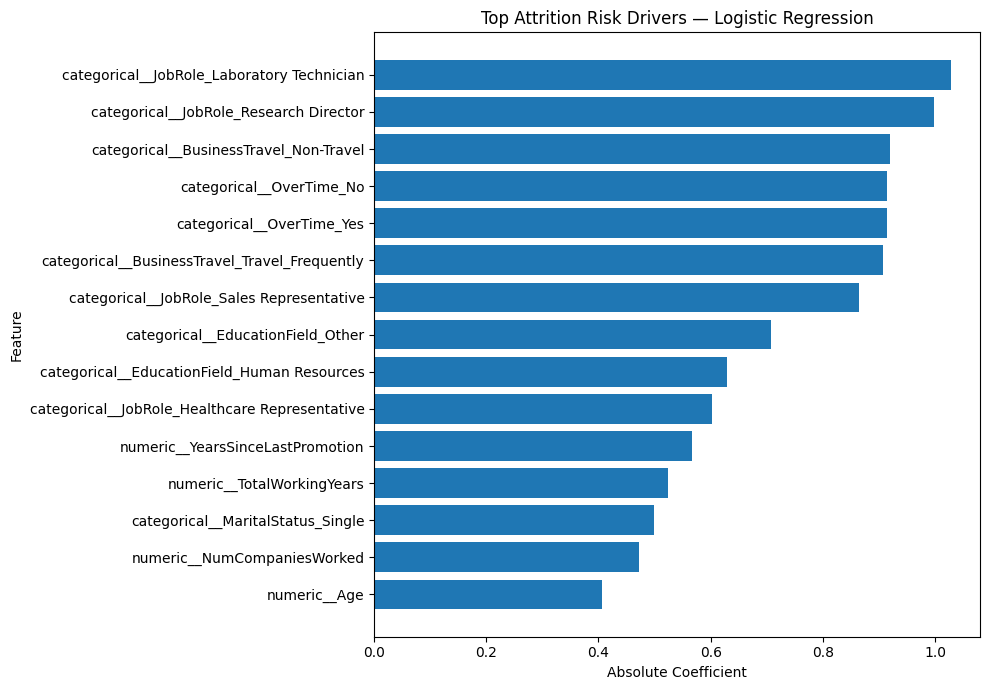

In [15]:
# ============================================================
# GLOBAL FEATURE IMPORTANCE
# ============================================================

top_features = (
    coefficient_df
    .head(15)
    .sort_values("AbsoluteImportance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["AbsoluteImportance"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top Attrition Risk Drivers — Logistic Regression")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# TOP FACTORS INCREASING ATTRITION RISK
# ============================================================

risk_increasing = (
    coefficient_df[
        coefficient_df["Coefficient"] > 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .head(15)
)

print("TOP FACTORS INCREASING ATTRITION RISK")
print("=" * 60)

display(
    risk_increasing[
        ["Feature", "Coefficient"]
    ]
)

TOP FACTORS INCREASING ATTRITION RISK


,Feature,Coefficient
0,categorical__JobRole_Laboratory Technician,1.028829
4,categorical__OverTime_Yes,0.913830
5,categorical__BusinessTravel_Travel_Frequently,0.906806
6,categorical__JobRole_Sales Representative,0.865041
8,categorical__EducationField_Human Resources,0.628815
10,numeric__YearsSinceLastPromotion,0.566500
12,categorical__MaritalStatus_Single,0.498468
13,numeric__NumCompaniesWorked,0.471908
15,numeric__DistanceFromHome,0.389561
16,categorical__EducationField_Technical Degree,0.383962


In [17]:
# ============================================================
# TOP FACTORS DECREASING ATTRITION RISK
# ============================================================

risk_decreasing = (
    coefficient_df[
        coefficient_df["Coefficient"] < 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=True
    )
    .head(15)
)

print("TOP FACTORS DECREASING ATTRITION RISK")
print("=" * 60)

display(
    risk_decreasing[
        ["Feature", "Coefficient"]
    ]
)

TOP FACTORS DECREASING ATTRITION RISK


,Feature,Coefficient
1,categorical__JobRole_Research Director,-0.997593
2,categorical__BusinessTravel_Non-Travel,-0.918983
3,categorical__OverTime_No,-0.914869
7,categorical__EducationField_Other,-0.707679
9,categorical__JobRole_Healthcare Representative,-0.601804
11,numeric__TotalWorkingYears,-0.523360
14,numeric__Age,-0.406360
17,numeric__YearsWithCurrManager,-0.382478
18,numeric__OverallSatisfactionScore,-0.374087
19,numeric__JobInvolvement,-0.369127


In [18]:
# ============================================================
# TEST SET PREDICTIONS
# ============================================================

test_probabilities = best_model.predict_proba(X_test)[:, 1]
test_predictions = best_model.predict(X_test)

explanation_df = X_test.copy()

explanation_df["ActualAttrition"] = y_test.values
explanation_df["PredictedAttrition"] = test_predictions
explanation_df["AttritionProbability"] = test_probabilities

print("✓ Test predictions generated.")

display(
    explanation_df[
        [
            "ActualAttrition",
            "PredictedAttrition",
            "AttritionProbability"
        ]
    ].head()
)

✓ Test predictions generated.


,ActualAttrition,PredictedAttrition,AttritionProbability
1061,0,0,0.079297
891,0,0,0.003449
456,0,0,0.133727
922,0,0,0.006895
69,1,0,0.277798


In [20]:
# ============================================================
# INDIVIDUAL EMPLOYEE EXPLANATION
# ============================================================

def explain_employee(row_number, X_data, probabilities):

    row = X_data.iloc[[row_number]]

    transformed_row = best_model.named_steps[
        "preprocessor"
    ].transform(row)

    transformed_row = np.asarray(transformed_row)

    contribution = (
        transformed_row[0] * model.coef_[0]
    )

    local_df = pd.DataFrame({
        "Feature": feature_names,
        "Contribution": contribution
    })

    local_df["AbsoluteContribution"] = (
        np.abs(local_df["Contribution"])
    )

    local_df["Direction"] = np.where(
        local_df["Contribution"] > 0,
        "Increases Risk",
        "Decreases Risk"
    )

    local_df = local_df.sort_values(
        by="AbsoluteContribution",
        ascending=False
    ).reset_index(drop=True)

    print("=" * 70)
    print(f"EMPLOYEE TEST ROW: {row_number}")
    print("=" * 70)

    print(
        f"Attrition Probability: "
        f"{probabilities[row_number]:.4f}"
    )

    print("\nTop contributing factors:")

    display(
        local_df.head(10)[
            [
                "Feature",
                "Contribution",
                "Direction"
            ]
        ]
    )

    return local_df

In [21]:
# ============================================================
# EXAMPLE INDIVIDUAL EXPLANATION
# ============================================================

employee_explanation = explain_employee(
    row_number=0,
    X_data=X_test.reset_index(drop=True),
    probabilities=test_probabilities
)

EMPLOYEE TEST ROW: 0
Attrition Probability: 0.0793

Top contributing factors:


,Feature,Contribution,Direction
0,categorical__BusinessTravel_Non-Travel,-0.918983,Decreases Risk
1,categorical__OverTime_No,-0.914869,Decreases Risk
2,categorical__JobRole_Sales Representative,0.865041,Increases Risk
3,numeric__TotalWorkingYears,0.695623,Increases Risk
4,numeric__Age,0.575741,Increases Risk
5,numeric__YearsWithCurrManager,0.450439,Increases Risk
6,numeric__YearsInCurrentRole,0.435931,Increases Risk
7,numeric__YearsSinceLastPromotion,-0.384747,Decreases Risk
8,numeric__EnvironmentSatisfaction,-0.325284,Decreases Risk
9,numeric__NumCompaniesWorked,-0.321508,Decreases Risk


In [22]:
# ============================================================
# SAVE GLOBAL EXPLAINABILITY RESULTS
# ============================================================

OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

global_explanation_path = (
    OUTPUT_PATH / "attrition_feature_explainability.csv"
)

coefficient_df.to_csv(
    global_explanation_path,
    index=False
)

print(
    f"✓ Saved global explainability:\n"
    f"{global_explanation_path}"
)

✓ Saved global explainability:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\eda_outputs\attrition_feature_explainability.csv


In [23]:
# ============================================================
# MODEL VERSIONING
# ============================================================

VERSION_PATH.mkdir(
    parents=True,
    exist_ok=True
)

versioned_model_path = (
    VERSION_PATH / "attrition_pipeline.joblib"
)

joblib.dump(
    best_model,
    versioned_model_path
)

print(
    f"✓ Versioned model saved:\n"
    f"{versioned_model_path}"
)

✓ Versioned model saved:
C:\Users\Shubham\Desktop\enterprise_hr_ai\models\v1\attrition_pipeline.joblib


In [24]:
# ============================================================
# MODEL METADATA
# ============================================================

best_metrics_path = (
    MODEL_PATH / "best_model_metrics.csv"
)

metrics_df = pd.read_csv(best_metrics_path)

best_metrics_row = metrics_df.iloc[0]

metadata = {
    "model_name": "Attrition Prediction Model",
    "version": "v1.0",
    "algorithm": "Logistic Regression",
    "selection_criterion": "ROC-AUC",
    "roc_auc": float(best_metrics_row["ROC-AUC"]),
    "precision": float(best_metrics_row["Precision"]),
    "recall": float(best_metrics_row["Recall"]),
    "f1_score": float(best_metrics_row["F1"]),
    "training_test_split": "80/20",
    "random_state": 42,
    "explainability_method": "Logistic Regression Coefficients",
    "xgboost_used": False
}

metadata

{'model_name': 'Attrition Prediction Model',
 'version': 'v1.0',
 'algorithm': 'Logistic Regression',
 'selection_criterion': 'ROC-AUC',
 'roc_auc': 0.8181583254371608,
 'precision': 0.6296296296296297,
 'recall': 0.3617021276595745,
 'f1_score': 0.4594594594594595,
 'training_test_split': '80/20',
 'random_state': 42,
 'explainability_method': 'Logistic Regression Coefficients',
 'xgboost_used': False}

In [25]:
# ============================================================
# SAVE MODEL METADATA
# ============================================================

metadata_path = (
    VERSION_PATH / "metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print(
    f"✓ Metadata saved:\n"
    f"{metadata_path}"
)

✓ Metadata saved:
C:\Users\Shubham\Desktop\enterprise_hr_ai\models\v1\metadata.json


In [26]:
# ============================================================
# VERIFY NOTEBOOK 09 ARTIFACTS
# ============================================================

artifacts = [
    global_explanation_path,
    versioned_model_path,
    metadata_path
]

print("NOTEBOOK 09 ARTIFACT VERIFICATION")
print("=" * 70)

for artifact in artifacts:

    if artifact.exists():
        print(f"✓ {artifact}")
    else:
        print(f"✗ MISSING: {artifact}")

NOTEBOOK 09 ARTIFACT VERIFICATION
✓ C:\Users\Shubham\Desktop\enterprise_hr_ai\data\eda_outputs\attrition_feature_explainability.csv
✓ C:\Users\Shubham\Desktop\enterprise_hr_ai\models\v1\attrition_pipeline.joblib
✓ C:\Users\Shubham\Desktop\enterprise_hr_ai\models\v1\metadata.json


In [27]:
# ============================================================
# NOTEBOOK 09 FINAL SUMMARY
# ============================================================

print("=" * 70)
print("NOTEBOOK 09 — MODEL EXPLAINABILITY + VERSIONING COMPLETE")
print("=" * 70)

print("\nModel:")
print("✓ Logistic Regression")

print("\nPerformance:")
print(f"✓ ROC-AUC  : {metadata['roc_auc']:.4f}")
print(f"✓ F1       : {metadata['f1_score']:.4f}")
print(f"✓ Recall   : {metadata['recall']:.4f}")
print(f"✓ Precision: {metadata['precision']:.4f}")

print("\nExplainability:")
print("✓ Global feature importance")
print("✓ Attrition risk drivers")
print("✓ Protective factors")
print("✓ Individual employee contribution analysis")

print("\nVersioning:")
print("✓ v1.0 model saved")
print("✓ metadata.json saved")

print("\nXGBoost:")
print("⚠ Not used — environment/DLL issue")

print("\n" + "=" * 70)
print("READY FOR NOTEBOOK 10")
print("=" * 70)

NOTEBOOK 09 — MODEL EXPLAINABILITY + VERSIONING COMPLETE

Model:
✓ Logistic Regression

Performance:
✓ ROC-AUC  : 0.8182
✓ F1       : 0.4595
✓ Recall   : 0.3617
✓ Precision: 0.6296

Explainability:
✓ Global feature importance
✓ Attrition risk drivers
✓ Protective factors
✓ Individual employee contribution analysis

Versioning:
✓ v1.0 model saved
✓ metadata.json saved

XGBoost:
⚠ Not used — environment/DLL issue

READY FOR NOTEBOOK 10
